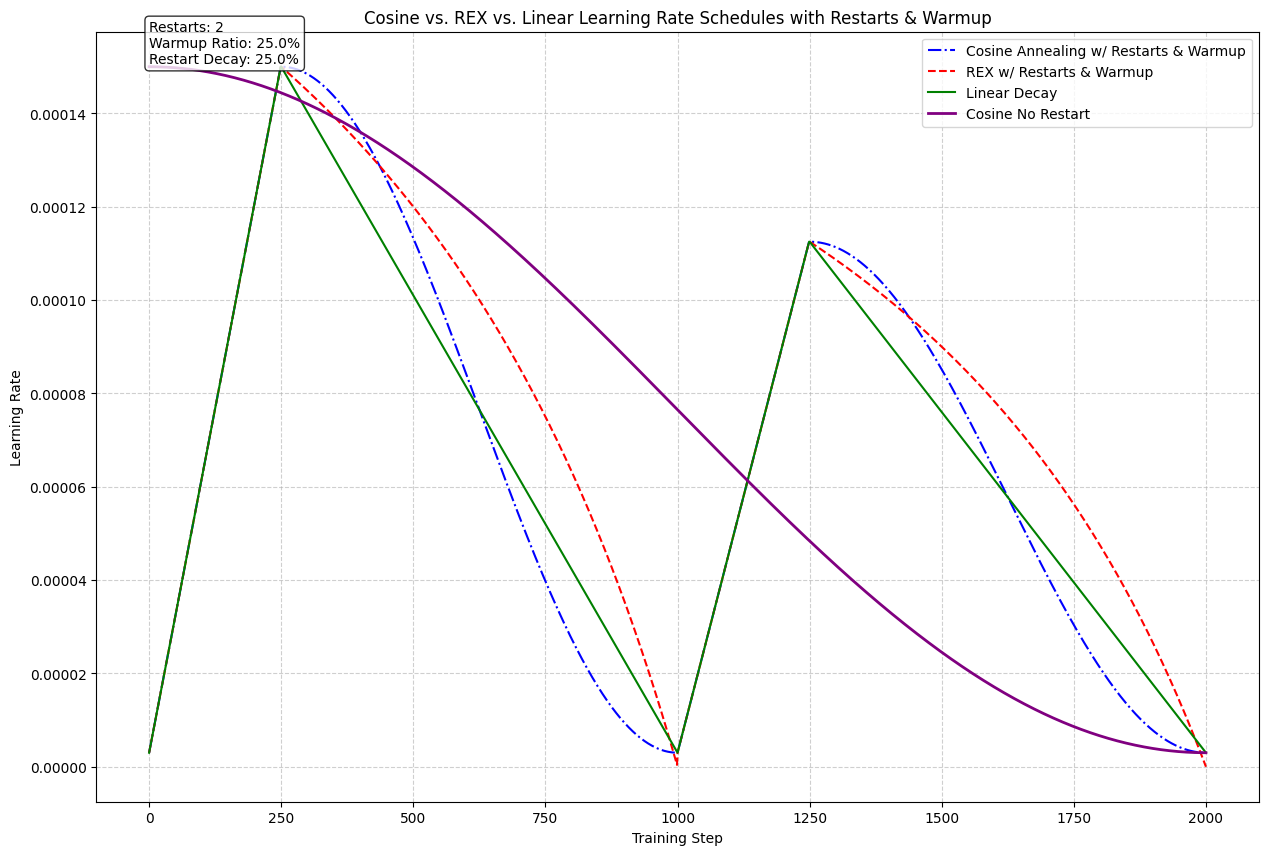

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
eta_max = 1.5e-04  # Initial learning rate
eta_min = 3e-06  # Minimum learning rate
T = 2000  # Total steps
num_restarts = 2  # Number of restarts
restart_decay = 0.2500  # Max learning rate decays by this factor per restart
warmup_ratio = 0.2500  # Fraction of each restart segment used for warmup

# Compute restart points
steps = np.arange(0, T+1)
lrs_cosine = np.zeros_like(steps, dtype=np.float32)
lrs_rex = np.zeros_like(steps, dtype=np.float32)
lrs_linear = np.zeros_like(steps, dtype=np.float32)
lrs_cosine_no_restart = eta_min + 0.5 * (eta_max - eta_min) * (1 + np.cos(np.pi * steps / T))

restart_points = np.linspace(0, T, num_restarts + 1, dtype=int)
current_eta_max_cosine = eta_max
current_eta_max_rex = eta_max
current_eta_max_linear = eta_max

# Compute schedules with restarts and per-restart warmup
for i in range(num_restarts):
    start, end = restart_points[i], restart_points[i+1]
    cycle_length = end - start
    warmup_steps = int(cycle_length * warmup_ratio)
    restart_steps = np.arange(0, cycle_length + 1)
    
    # Warmup phase
    warmup_lrs_cosine = np.linspace(eta_min, current_eta_max_cosine, warmup_steps)
    warmup_lrs_rex = np.linspace(eta_min, current_eta_max_rex, warmup_steps)
    warmup_lrs_linear = np.linspace(eta_min, current_eta_max_linear, warmup_steps)
    
    lrs_cosine[start:start+warmup_steps] = warmup_lrs_cosine
    lrs_rex[start:start+warmup_steps] = warmup_lrs_rex
    lrs_linear[start:start+warmup_steps] = warmup_lrs_linear
    
    cos_start = rex_start = linear_start = start + warmup_steps
    
    # Cosine decay phase
    lrs_cosine[cos_start:end+1] = eta_min + 0.5 * (current_eta_max_cosine - eta_min) * (1 + np.cos(np.pi * restart_steps[:end - cos_start + 1] / (end - cos_start)))
    
    # REX decay phase
    rex_decay_steps = restart_steps[:end - rex_start + 1]
    lrs_rex[rex_start:end+1] = current_eta_max_rex * ((1 - rex_decay_steps / (end - rex_start)) / (0.5 + 0.5 * (1 - rex_decay_steps / (end - rex_start))))
    
    # Linear decay phase
    lrs_linear[linear_start:end+1] = np.linspace(current_eta_max_linear, eta_min, end - linear_start + 1)
    
    # Apply decay factor
    current_eta_max_cosine *= (1 - restart_decay)
    current_eta_max_rex *= (1 - restart_decay)
    current_eta_max_linear *= (1 - restart_decay)

# Plot
plt.figure(figsize=(15, 10))
plt.plot(steps, lrs_cosine, label='Cosine Annealing w/ Restarts & Warmup', color='b', linestyle='-.')
plt.plot(steps, lrs_rex, label='REX w/ Restarts & Warmup', color='r', linestyle='--')
plt.plot(steps, lrs_linear, label='Linear Decay', color='g')
plt.plot(steps, lrs_cosine_no_restart, label='Cosine No Restart', color='purple', linewidth=2)
plt.xlabel("Training Step")
plt.ylabel("Learning Rate")
plt.title("Cosine vs. REX vs. Linear Learning Rate Schedules with Restarts & Warmup")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Add information box
info_text = f"Restarts: {num_restarts}\nWarmup Ratio: {warmup_ratio*100:.1f}%\nRestart Decay: {restart_decay*100:.1f}%"
props = dict(boxstyle='round', facecolor='white', alpha=0.8)
plt.text(steps[0], eta_max, info_text, fontsize=10, verticalalignment='bottom', horizontalalignment='left', bbox=props)

plt.show()

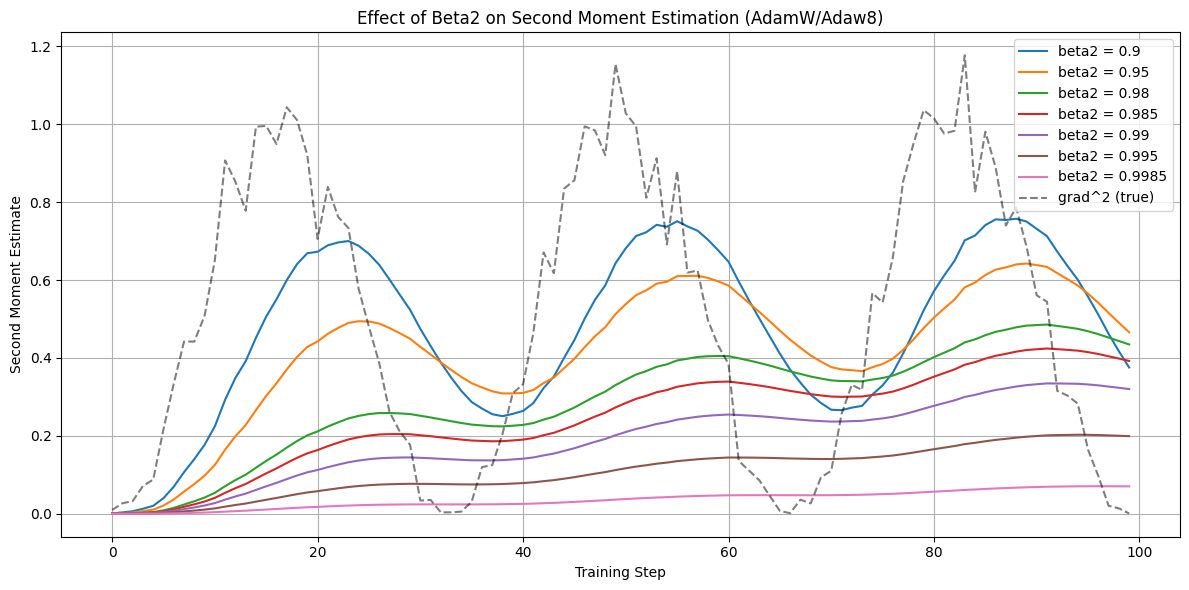

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Simulate how beta2 affects second moment estimation in AdamW/Adam-like optimizers

steps = 100
grad_sq = np.abs(np.sin(np.linspace(0, 3 * np.pi, steps)) + np.random.normal(0, 0.05, steps)) ** 2

# Different beta2 values
beta2_vals = [0.9, 0.95, 0.98, 0.985, 0.99, 0.995, 0.9985]
momentums = {beta: [] for beta in beta2_vals}

for beta2 in beta2_vals:
    v = 0
    for g2 in grad_sq:
        v = beta2 * v + (1 - beta2) * g2
        momentums[beta2].append(v)

# Plot
plt.figure(figsize=(12, 6))
for beta2 in beta2_vals:
    plt.plot(momentums[beta2], label=f"beta2 = {beta2}")
plt.plot(grad_sq, color="black", linestyle="--", alpha=0.5, label="grad^2 (true)")
plt.title("Effect of Beta2 on Second Moment Estimation (AdamW/Adaw8)")
plt.xlabel("Training Step")
plt.ylabel("Second Moment Estimate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
